In [1]:
hindi_name = u'\u092E\u094B\u0939\u093F\u0924 \u0915\u0941\u092E\u093E\u0930'
print(hindi_name)

मोहित कुमार


In [2]:
!pip install mlxtend


In [28]:
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.pyplot as plt

In [4]:
file_path = "Market_Basket_Optimisation.csv"
dataset = pd.read_csv(file_path, header=None)

In [5]:

# Data Preprocessing: Replace NaN values and convert to list of transactions
dataset.fillna('', inplace=True)
transactions = []
for i in range(0, len(dataset)):
    transaction = [str(item) for item in dataset.iloc[i] if item != '']
    transactions.append(transaction)

In [6]:
# Convert transactions into one-hot encoded format
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)
df.head()

,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,True,True,False,True,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [7]:

# Define the function to get association rules with given support and confidence
def get_rules(min_support, min_confidence):
    frequent_itemsets = apriori(df, min_support=min_support, use_colnames=True)
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)
    return rules

# Initialize the list to store results
results = []

# Try different values for support and confidence
support_values = [0.01, 0.02, 0.03, 0.04]
confidence_values = [0.2, 0.3, 0.4, 0.5]

for support in support_values:
    for confidence in confidence_values:
        rules = get_rules(support, confidence)
        results.append({
            'support': support,
            'confidence': confidence,
            'num_rules': len(rules)
        })

# Convert results to a DataFrame for easy viewing
results_df = pd.DataFrame(results)

# Display the results
print(results_df)

# You can then select the optimal combination based on the number of rules generated.


    support  confidence  num_rules
0      0.01         0.2        162
1      0.01         0.3         63
2      0.01         0.4         18
3      0.01         0.5          2
4      0.02         0.2         55
5      0.02         0.3         20
6      0.02         0.4          3
7      0.02         0.5          0
8      0.03         0.2         27
9      0.03         0.3          7
10     0.03         0.4          1
11     0.03         0.5          0
12     0.04         0.2          9
13     0.04         0.3          4
14     0.04         0.4          1
15     0.04         0.5          0


In [1]:

# Finding connected rules through overlapping itemsets
connected_rules = []

print("\nConnected Rules (via overlapping items):")
for i in range(len(rules)):
    for j in range(i + 1, len(rules)):
        rule_i_antecedents = set(rules.iloc[i]['antecedents'])
        rule_j_antecedents = set(rules.iloc[j]['antecedents'])
        rule_i_consequents = set(rules.iloc[i]['consequents'])
        rule_j_consequents = set(rules.iloc[j]['consequents'])

        # Check for overlap in antecedents or consequents
        if rule_i_antecedents & rule_j_antecedents or rule_i_consequents & rule_j_consequents:
            shared_antecedents = rule_i_antecedents & rule_j_antecedents
            shared_consequents = rule_i_consequents & rule_j_consequents
            connected_rules.append([
                f"Rule {i + 1}: {rules.iloc[i]['antecedents']} -> {rules.iloc[i]['consequents']}",
                f"Rule {j + 1}: {rules.iloc[j]['antecedents']} -> {rules.iloc[j]['consequents']}",
                list(shared_antecedents) if shared_antecedents else list(shared_consequents)
            ])

# Define headers for the table
headers = ['Rule 1', 'Rule 2', 'Shared Items']

# Print the connected rules in a table format using tabulate
if connected_rules:
    print(tabulate(connected_rules, headers=headers, tablefmt='pretty'))
else:
    print("No connected rules found.")

# Displaying the count of rules
rule_count = rules.shape[0]
print(f"\nTotal number of association rules: {rule_count}")



Connected Rules (via overlapping items):


NameError: name 'rules' is not defined

In [ ]:
# Train Apriori algorithm on the dataset with a minimum support of 0.02
frequent_itemsets = apriori(df, min_support=0.02, use_colnames=True)

In [ ]:
# Calculate the lift for the rules if not already calculated
rules['lift'] = rules['confidence'] / (rules['support'] / (df_encoded.shape[0]))

# Select relevant columns for better readability
rules_display = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

# Print the association rules in a neat table format
#print("\nAssociation Rules (with Support, Confidence, and Lift):")
#print(tabulate(rules_display, headers='keys', tablefmt='pretty', showindex=False))

# Relationship summary
relationship_summary = []

# Add relationship details for each rule
for _, row in rules.iterrows():
    relationship_summary.append([
        row['antecedents'],
        row['consequents'],
        row['support'],
        row['confidence'],
        row['lift']
    ])

# Define headers for the relationship summary table
summary_headers = ['Antecedents', 'Consequents', 'Support', 'Confidence', 'Lift']

# Print the relationship summary in a table format using tabulate
print("\nRelationship Summary:")
print(tabulate(relationship_summary, headers=summary_headers, tablefmt='pretty'))

In [ ]:
# Generate association rules with a minimum confidence of 0.3
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)


In [ ]:
# Determine the maximum length of itemsets
max_length = frequent_itemsets['itemsets'].apply(len).max()

# Filter the frequent itemsets that have the maximum length
last_table = frequent_itemsets[frequent_itemsets['itemsets'].apply(len) == max_length]

# Rounding the support values to 3 decimal places
last_table = last_table.round(3)

# Display the last table of frequent itemsets
print(last_table)



In [58]:
# Display the generated rules with values rounded to 2 decimal points
rounded_rules = rules.round(2)  # Round all numeric columns to 2 decimal points
print(rounded_rules.head(20).to_string(index=True))

            antecedents      consequents  antecedent support  consequent support  support  confidence  lift  leverage  conviction  zhangs_metric
0             (burgers)           (eggs)                0.09                0.18     0.03        0.33  1.84      0.01        1.22           0.50
1                (cake)  (mineral water)                0.08                0.24     0.03        0.34  1.42      0.01        1.15           0.32
2             (chicken)  (mineral water)                0.06                0.24     0.02        0.38  1.59      0.01        1.23           0.40
3           (chocolate)  (mineral water)                0.16                0.24     0.05        0.32  1.35      0.01        1.12           0.31
4         (cooking oil)  (mineral water)                0.05                0.24     0.02        0.39  1.65      0.01        1.26           0.42
5     (frozen smoothie)  (mineral water)                0.06                0.24     0.02        0.32  1.34      0.01        1.12 

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


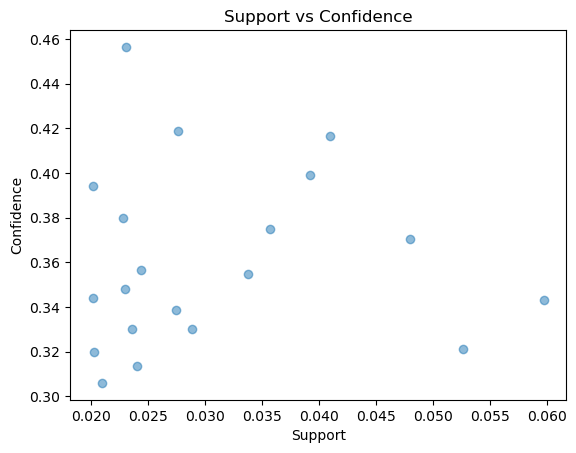

In [12]:
# Plotting support vs confidence for rules
plt.scatter(rules['support'], rules['confidence'], alpha=0.5)
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence')
plt.show()

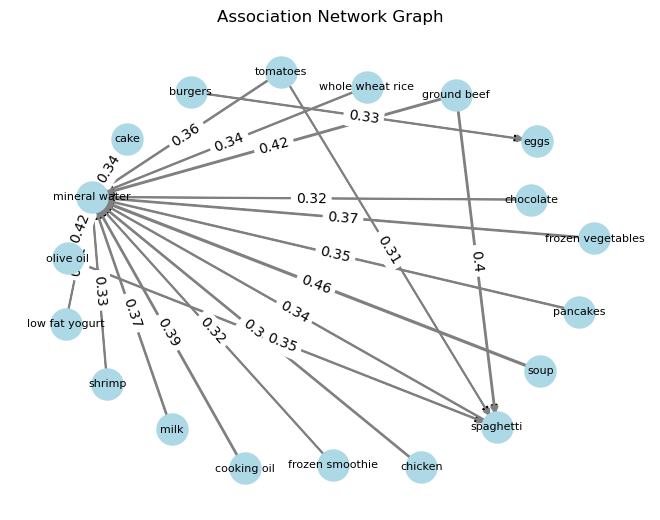

In [52]:


# Initialize a directed graph
G = nx.DiGraph()

# Add edges to the graph based on association rules
for _, rule in rules.iterrows():
    antecedents = ', '.join(list(rule['antecedents']))
    consequents = ', '.join(list(rule['consequents']))
    G.add_edge(antecedents, consequents, weight=rule['confidence'])

# Define the layout for the graph
pos = nx.spring_layout(G, k=500)  # 'k' controls the distance between nodes

# Draw the nodes with labels
nx.draw(G, pos, with_labels=True, node_size=500, node_color='lightblue', font_size=8, arrows=True)

# Draw edges with varying thickness based on confidence (rule strength)
edges = G.edges(data=True)
nx.draw_networkx_edges(G, pos, edgelist=edges, width=[rule['weight']*5 for (_, _, rule) in edges], edge_color='gray')

# Add labels to edges (showing the confidence of the rule)
edge_labels = {(ante, cons): f"{round(data['weight'], 2)}" for (ante, cons, data) in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Show the graph
plt.title("Association Network Graph")
plt.show()
